In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys
sys.path.append("../../")
from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader, Dataset
from vi_rnn.datasets import Reaching, Reaching_Teacher, Mante, Mante_Teacher
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from py_rnn.default_params import get_default_params

%matplotlib inline

In [2]:
train_teacher = False # load already trained teacher model
data_dir = "../../data/student_teacher/"  # store inferred model
model_dir = "../../models/students/"  # store teacher RNN
cuda = True  # toggle if GPU is available

In [3]:
# initialise teacher RNN
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 1000
training_params["l2_rates_reg"] = 0.1
model_params['rank']= 1
model_params['n_inp'] = 2
model_params["neuromodulation"] = "additive" 
model_params["ds"] = 2 
model_params["dz"] = 1
training_params["neuromodulation"] = "additive"
rnn_reach = RNN(model_params)

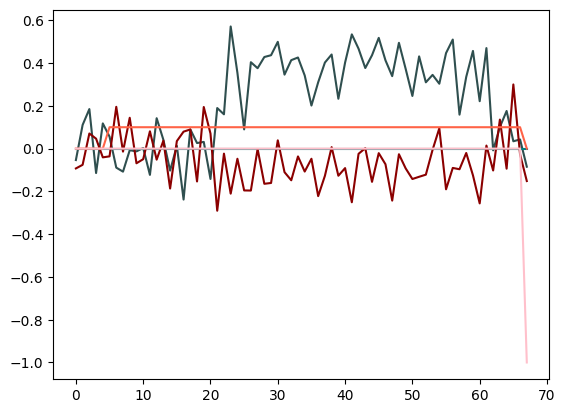

In [4]:
# Plot an example trial for teacher RNN

mante = Mante()
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

In [5]:
task_params_teacher = {}
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_reach, training_params, mante, sync_wandb=False
    )
    save_rnn(
        data_dir + "cdm_rnn3",
        rnn_reach,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_reach, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + "cdm_rnn3"
    )

c:\Users\kaleab.belay\Documents\project\mnm\train_scripts\student_teacher\../..\py_rnn\train.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torc

In [6]:
rnn_reach.rnn.neuromodulation

'additive'

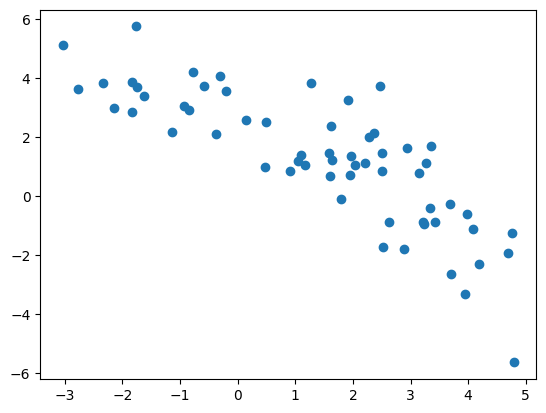

In [7]:
plt.scatter(rnn_reach.rnn.A[:, 0].detach(), rnn_reach.rnn.A[:, 1].detach())

In [9]:
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()
A = rnn_reach.rnn.A.detach()

In [19]:
# Generate data using teacher RNN, used for training student RNN
batch_size = 4
task_params = {
    "name": "rdm",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "n_trials": 300,
    "neuromodulation": "additive",
    "dz": 1, 
    "du": 2
}
task = Mante_Teacher(task_params, task_params_teacher, U, V, B, I, A=A, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=True)

In [20]:
task.stim.shape

torch.Size([300, 68, 2])

In [23]:
# Initialise VI / student setup

dim_z = 1
dim_N = task_params["n_neurons"]
dim_x = task_params["n_neurons"]
dim_u = 2
dim_s = 2
bs = 10
cuda = True
n_epochs = 500
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params["out"],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulation": "additive"
}


training_params = {
    "lr": 2e-3,
    "lr_end": 1e-5,
    "step_size":1,
    "opt_eps": 1e-8,
    "gamma":.99,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 50,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": False,
    "smooth_at_eval": False,
    "sim_v":True,
    "neuromodulation": "additive"
}


VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "dim_s": dim_s,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal":True,
}
vae = VAE(VAE_params)

Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1


In [24]:
# Train

train_VAE(
    vae,
    training_params,
    task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cpu
Learning rate decay factor 0.9894593118113242
epoch 1 loss: 691.6406, ll: -691.6406, ll_x: 690.4103, ll_z: -1.2578 H: 2.4926, alpha: 0.94, lr: 0.002000, N_z: 0.0996, N_x: 0.1081
epoch 2 loss: 665.1643, ll: -665.1643, ll_x: 663.9690, ll_z: -1.2818 H: 2.4835, alpha: 0.94, lr: 0.001980, N_z: 0.0992, N_x: 0.1086
epoch 3 loss: 653.4384, ll: -653.4384, ll_x: 652.2613, ll_z: -1.2950 H: 2.4793, alpha: 0.94, lr: 0.001960, N_z: 0.0987, N_x: 0.1091
epoch 4 loss: 639.3196, ll: -639.3196, ll_x: 638.1572, ll_z: -1.3045 H: 2.4746, alpha: 0.94, lr: 0.001941, N_z: 0.0980, N_x: 0.1098
epoch 5 loss: 623.4253, ll: -623.4253, ll_x: 622.2769, ll_z: -1.3131 H: 2.4696, alpha: 0.94, lr: 0.001921, N_z: 0.0973, N_x: 0.1105
epoch 6 loss: 606.2396, ll: -606.2396, ll_x: 605.1058, ll_z: -1.3211 H: 2.4632, alpha: 0.94, lr: 0.001902, N_z: 0.0965, N_x: 0.1113
epoch 7 loss: 588.0911, ll: -588.0911, ll_x: 586.9714, ll_z: -1.3288 H: 2.4569, alpha: 0.94, lr: 0.001883, N_z: 0.0956, N_x: 0.1121
epoch 8 loss

KeyboardInterrupt: 

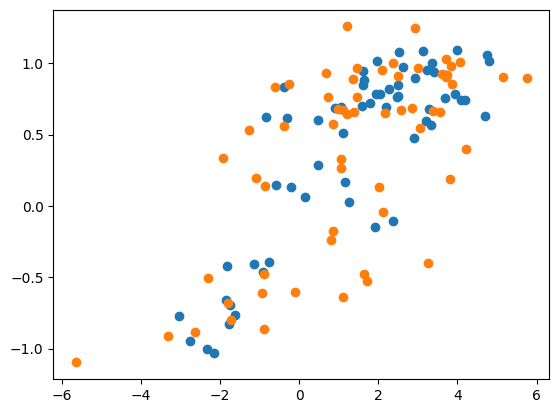

In [25]:
plt.scatter(rnn_reach.rnn.A[:, 0].detach(), vae.rnn.transition.A[:, 0].detach())
plt.scatter(rnn_reach.rnn.A[:, 1].detach(), vae.rnn.transition.A[:, 1].detach())